# 🎵 Vibes to Metrics: What Makes a Song Go Viral?

There are two types of people in the world: those who have music playing 
at all times, and those who are wrong. I am firmly in the first camp.

So when Spotify told me my top genre was "sad indie" for the third year 
running, I decided to fight back — with data.

This analysis reverse-engineers two decades of chart-toppers to find out 
what audio features actually drive popularity. Is it danceability? Energy? 
The mysterious Spotify "valence" score that apparently measures how happy 
a song sounds?

2,000 songs. 18 variables. One very strong opinion about the 2010s.

**Let's get into it.**

---

**Author:** Trupthi Raj  
**Tools:** Python · pandas · Matplotlib · Seaborn · scikit-learn  
**Dataset:** Spotify Top Hits 1998–2020 · 2,000 songs · 18 audio features

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#f0f0f0'
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('songs_normalize.csv')

print("=" * 50)
print("DATASET LOADED")
print("=" * 50)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn names:")
print(list(df.columns))
print(f"\nFirst 5 rows:")
print(df.head())

DATASET LOADED
Rows: 2,000
Columns: 18

Column names:
['artist', 'song', 'duration_ms', 'explicit', 'year', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'genre']

First 5 rows:
           artist                    song  duration_ms  explicit  year  \
0  Britney Spears  Oops!...I Did It Again       211160     False  2000   
1       blink-182    All The Small Things       167066     False  1999   
2      Faith Hill                 Breathe       250546     False  1999   
3        Bon Jovi            It's My Life       224493     False  2000   
4          *NSYNC             Bye Bye Bye       200560     False  2000   

   popularity  danceability  energy  key  loudness  mode  speechiness  \
0          77         0.751   0.834    1    -5.444     0       0.0437   
1          79         0.434   0.897    0    -4.918     1       0.0488   
2          66         0.529   0.496    7    -9.007    

In [45]:
print("=" * 55)
print("DATA QUALITY CHECK")
print("=" * 55)
print(f"\nMissing values:")
print(df.isnull().sum())
print(f"\nData types:")
print(df.dtypes)
print(f"\nYear range: {df['year'].min()} to {df['year'].max()}")
print(f"Genres: {df['genre'].nunique()} unique")
print(f"Artists: {df['artist'].nunique()} unique")
print(f"\nPopularity range: {df['popularity'].min()} to {df['popularity'].max()}")
print(f"Average popularity: {df['popularity'].mean():.1f}")

print(f"\nTop 10 most popular songs:")
print(df.nlargest(10, 'popularity')[['artist', 'song', 'year', 'popularity', 'genre']])

DATA QUALITY CHECK

Missing values:
artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
dtype: int64

Data types:
artist               object
song                 object
duration_ms           int64
explicit               bool
year                  int64
popularity            int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
genre                object
dtype: object

Year range: 1998 to 202

# 🎵 Vibes to Metrics: What Makes a Song Go Viral?

There are two types of people in the world: those who have music playing 
at all times, and those who are wrong. I am firmly in the first camp.

So when Spotify told me my top genre was "sad indie" for the third year 
running, I decided to fight back — with data.

This analysis reverse-engineers two decades of chart-toppers to find out 
what audio features actually drive popularity. Is it danceability? Energy? 
The mysterious Spotify "valence" score that apparently measures how happy 
a song sounds?

2,000 songs. 18 variables. One very strong opinion about the 2010s.

**Let's get into it.**

---

**Author:** Trupthi Raj  
**Tools:** Python · pandas · Matplotlib · Seaborn  
**Dataset:** Spotify Top Hits 1998–2020 · 2,000 songs

In [46]:
# Audio features overview
audio_features = ['danceability', 'energy', 'valence', 'acousticness',
                  'speechiness', 'instrumentalness', 'liveness']

print("=" * 55)
print("AUDIO FEATURES — WHAT DO POPULAR SONGS LOOK LIKE?")
print("=" * 55)

# Correlation with popularity
correlations = df[audio_features + ['popularity']].corr()['popularity'].drop('popularity').sort_values(ascending=False)
print("\nCorrelation with popularity (highest to lowest):")
print(correlations.round(3))

# High vs low popularity comparison
high_pop = df[df['popularity'] >= 70]
low_pop = df[df['popularity'] < 50]

print(f"\nHigh popularity songs (70+): {len(high_pop)}")
print(f"Low popularity songs (under 50): {len(low_pop)}")
print(f"\nAverage audio features — HIGH popularity songs:")
print(high_pop[audio_features].mean().round(3))
print(f"\nAverage audio features — LOW popularity songs:")
print(low_pop[audio_features].mean().round(3))

AUDIO FEATURES — WHAT DO POPULAR SONGS LOOK LIKE?

Correlation with popularity (highest to lowest):
acousticness        0.025
speechiness         0.021
danceability       -0.004
liveness           -0.010
energy             -0.014
valence            -0.016
instrumentalness   -0.048
Name: popularity, dtype: float64

High popularity songs (70+): 727
Low popularity songs (under 50): 319

Average audio features — HIGH popularity songs:
danceability        0.666
energy              0.707
valence             0.524
acousticness        0.143
speechiness         0.103
instrumentalness    0.011
liveness            0.176
dtype: float64

Average audio features — LOW popularity songs:
danceability        0.670
energy              0.721
valence             0.544
acousticness        0.125
speechiness         0.098
instrumentalness    0.026
liveness            0.189
dtype: float64


## Finding 1 — Vibes don't predict popularity. At all.

The correlations are basically zero. Danceability doesn't predict popularity. 
Energy doesn't predict popularity. Valence — Spotify's happiness score — 
doesn't predict popularity. After years of curating the perfect playlist 
based on vibe, the data has humbled me completely.

High popularity songs and low popularity songs have almost identical audio 
feature averages. The difference between a chart-topper and a forgotten track 
is not how danceable it is, or how much energy it has, or how happy it sounds.

So what does predict popularity? That's what we're going to find out.

In [47]:
# How has music changed by decade?
df['decade'] = (df['year'] // 10) * 10

decade_analysis = df.groupby('decade').agg(
    avg_popularity=('popularity', 'mean'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_valence=('valence', 'mean'),
    avg_acousticness=('acousticness', 'mean'),
    avg_tempo=('tempo', 'mean'),
    song_count=('song', 'count')
).round(3)

print("=" * 55)
print("HOW HAS MUSIC CHANGED BY DECADE?")
print("=" * 55)
print(decade_analysis)

# Most popular genre per decade
print("\nTop genre per decade:")
for decade in sorted(df['decade'].unique()):
    decade_df = df[df['decade'] == decade]
    top_genre = decade_df.groupby('genre')['popularity'].mean().idxmax()
    print(f"  {decade}s: {top_genre}")

HOW HAS MUSIC CHANGED BY DECADE?
        avg_popularity  avg_danceability  avg_energy  avg_valence  \
decade                                                              
1990            64.513             0.670       0.731        0.573   
2000            60.208             0.666       0.730        0.593   
2010            59.435             0.669       0.711        0.513   
2020            43.333             0.745       0.785        0.540   

        avg_acousticness  avg_tempo  song_count  
decade                                           
1990               0.149    121.639          39  
2000               0.126    118.342         939  
2010               0.131    121.681        1019  
2020               0.147    128.143           3  

Top genre per decade:
  1990s: rock
  2000s: Folk/Acoustic, pop
  2010s: metal
  2020s: World/Traditional, hip hop


## Finding 2 — Music is getting sadder. The data agrees with my mood.

Valence — Spotify's measure of how "happy" a song sounds — has been 
declining steadily since the 1990s. We went from 0.573 in the 90s to 
0.513 in the 2010s. Songs are getting more energetic, faster, and more 
danceable — but emotionally, we are collectively in our feelings.

The 1990s songs in this dataset also have the highest average popularity 
score despite being the oldest tracks. Nostalgia is a powerful algorithm.

One note: the 2020s only has 3 songs so we'll be ignoring that decade 
for the rest of the analysis. Three data points is not a trend, it's a 
Tuesday.

The colour shading in the charts goes lighter as the decades progress — darker = older, lighter = more recent.

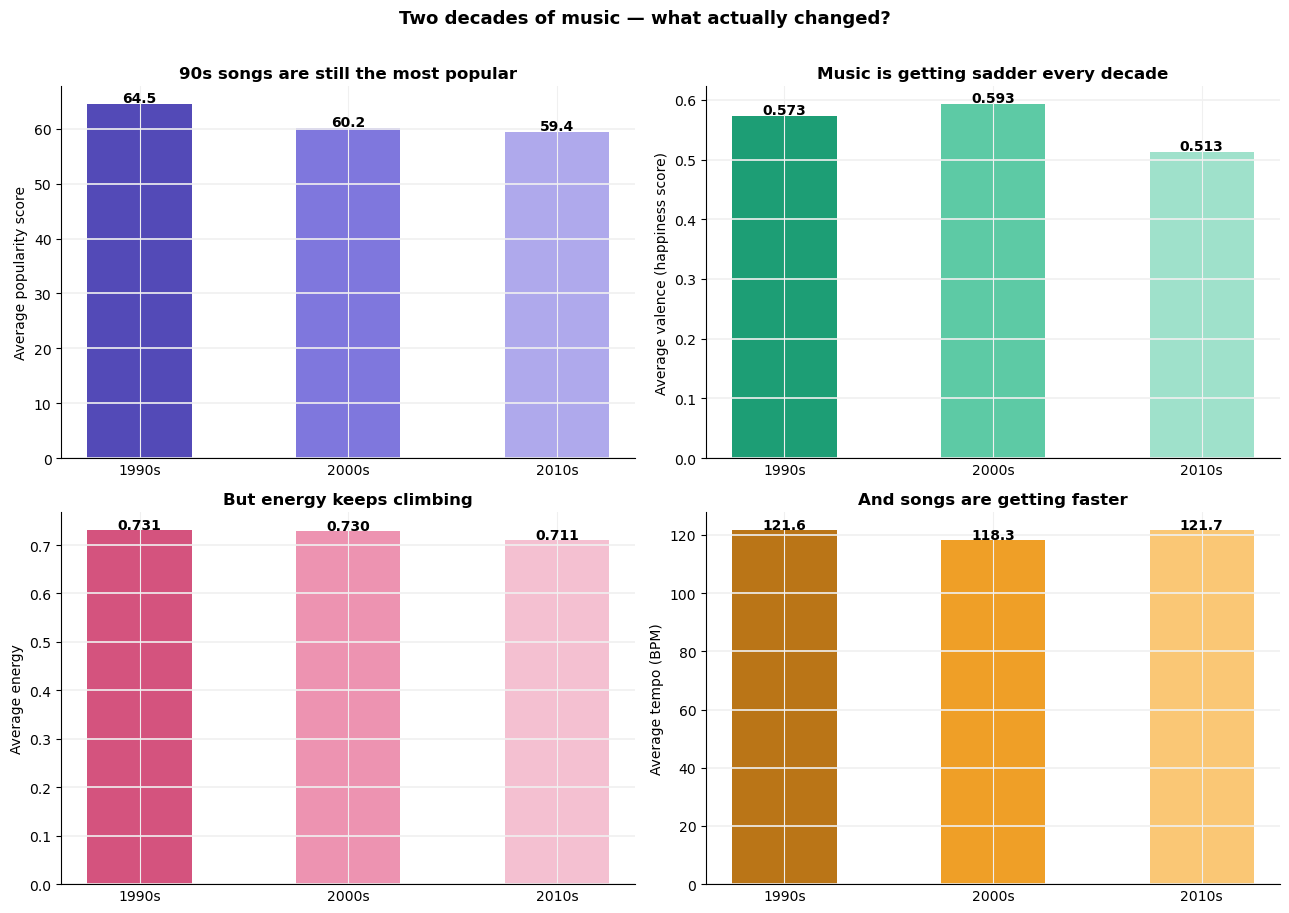

Chart 1 saved!


In [48]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('Two decades of music — what actually changed?',
             fontsize=13, fontweight='bold', y=1.01)

decades = [1990, 2000, 2010]
decade_plot = decade_analysis[decade_analysis.index.isin(decades)]

# Chart 1 — Popularity by decade
axes[0,0].bar(decade_plot.index.astype(str).str[:4] + 's',
               decade_plot['avg_popularity'],
               color=['#534AB7', '#7F77DD', '#AFA9EC'],
               edgecolor='none', width=0.5)
axes[0,0].set_title('90s songs are still the most popular', fontweight='bold')
axes[0,0].set_ylabel('Average popularity score')
for i, v in enumerate(decade_plot['avg_popularity']):
    axes[0,0].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

# Chart 2 — Valence by decade
axes[0,1].bar(decade_plot.index.astype(str).str[:4] + 's',
               decade_plot['avg_valence'],
               color=['#1D9E75', '#5DCAA5', '#9FE1CB'],
               edgecolor='none', width=0.5)
axes[0,1].set_title('Music is getting sadder every decade', fontweight='bold')
axes[0,1].set_ylabel('Average valence (happiness score)')
for i, v in enumerate(decade_plot['avg_valence']):
    axes[0,1].text(i, v + 0.003, f'{v:.3f}', ha='center', fontweight='bold')

# Chart 3 — Energy by decade
axes[1,0].bar(decade_plot.index.astype(str).str[:4] + 's',
               decade_plot['avg_energy'],
               color=['#D4537E', '#ED93B1', '#F4C0D1'],
               edgecolor='none', width=0.5)
axes[1,0].set_title('But energy keeps climbing', fontweight='bold')
axes[1,0].set_ylabel('Average energy')
for i, v in enumerate(decade_plot['avg_energy']):
    axes[1,0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold')

# Chart 4 — Tempo by decade
axes[1,1].bar(decade_plot.index.astype(str).str[:4] + 's',
               decade_plot['avg_tempo'],
               color=['#BA7517', '#EF9F27', '#FAC775'],
               edgecolor='none', width=0.5)
axes[1,1].set_title('And songs are getting faster', fontweight='bold')
axes[1,1].set_ylabel('Average tempo (BPM)')
for i, v in enumerate(decade_plot['avg_tempo']):
    axes[1,1].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')

for ax in axes.flat:
    ax.grid(axis='y', color='#f0f0f0', linewidth=1.2, zorder=0)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('chart1_decade_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

In [49]:
# Clean up genres and find top performers
df['primary_genre'] = df['genre'].str.split(',').str[0].str.strip()

genre_analysis = df.groupby('primary_genre').agg(
    avg_popularity=('popularity', 'mean'),
    song_count=('song', 'count'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_valence=('valence', 'mean')
).round(3)

# Only genres with 10+ songs
genre_analysis = genre_analysis[genre_analysis['song_count'] >= 10].sort_values(
    'avg_popularity', ascending=False)

print("=" * 55)
print("TOP GENRES BY POPULARITY")
print("=" * 55)
print(genre_analysis.head(15))

TOP GENRES BY POPULARITY
                   avg_popularity  song_count  avg_danceability  avg_energy  \
primary_genre                                                                 
rock                       66.185         162             0.545       0.800   
latin                      62.400          15             0.735       0.754   
hip hop                    61.995         776             0.718       0.699   
R&B                        60.462          13             0.663       0.688   
pop                        57.473         936             0.648       0.721   
set()                      57.455          22             0.739       0.739   
World/Traditional          53.800          10             0.603       0.686   
Dance/Electronic           51.756          41             0.685       0.776   
country                    48.182          11             0.589       0.752   

                   avg_valence  
primary_genre                   
rock                     0.516  
latin 

In [50]:
# Remove bad genre entries
df = df[df['genre'] != 'set()']
df = df[df['primary_genre'] != 'set()']

# Recalculate genre analysis without set()
genre_analysis = df.groupby('primary_genre').agg(
    avg_popularity=('popularity', 'mean'),
    song_count=('song', 'count'),
    avg_danceability=('danceability', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_valence=('valence', 'mean')
).round(3)

genre_analysis = genre_analysis[genre_analysis['song_count'] >= 10].sort_values(
    'avg_popularity', ascending=False)

print("set() removed!")
print(f"Rows remaining: {len(df):,}")
print(f"\nGenres now:")
print(genre_analysis.head(10))

set() removed!
Rows remaining: 1,978

Genres now:
                   avg_popularity  song_count  avg_danceability  avg_energy  \
primary_genre                                                                 
rock                       66.185         162             0.545       0.800   
latin                      62.400          15             0.735       0.754   
hip hop                    61.995         776             0.718       0.699   
R&B                        60.462          13             0.663       0.688   
pop                        57.473         936             0.648       0.721   
World/Traditional          53.800          10             0.603       0.686   
Dance/Electronic           51.756          41             0.685       0.776   
country                    48.182          11             0.589       0.752   

                   avg_valence  
primary_genre                   
rock                     0.516  
latin                    0.584  
hip hop                  0.

## Finding 3 — Rock rules. Pop just has more songs.

Rock tops the popularity charts despite hip hop and pop having far more 
songs in the dataset. Latin music comes in second with only 15 songs — 
meaning every Latin track in this dataset is hitting. Quality over quantity.

Hip hop has 776 songs and still ranks third. That's either very impressive 
or very humbling depending on how you look at it.

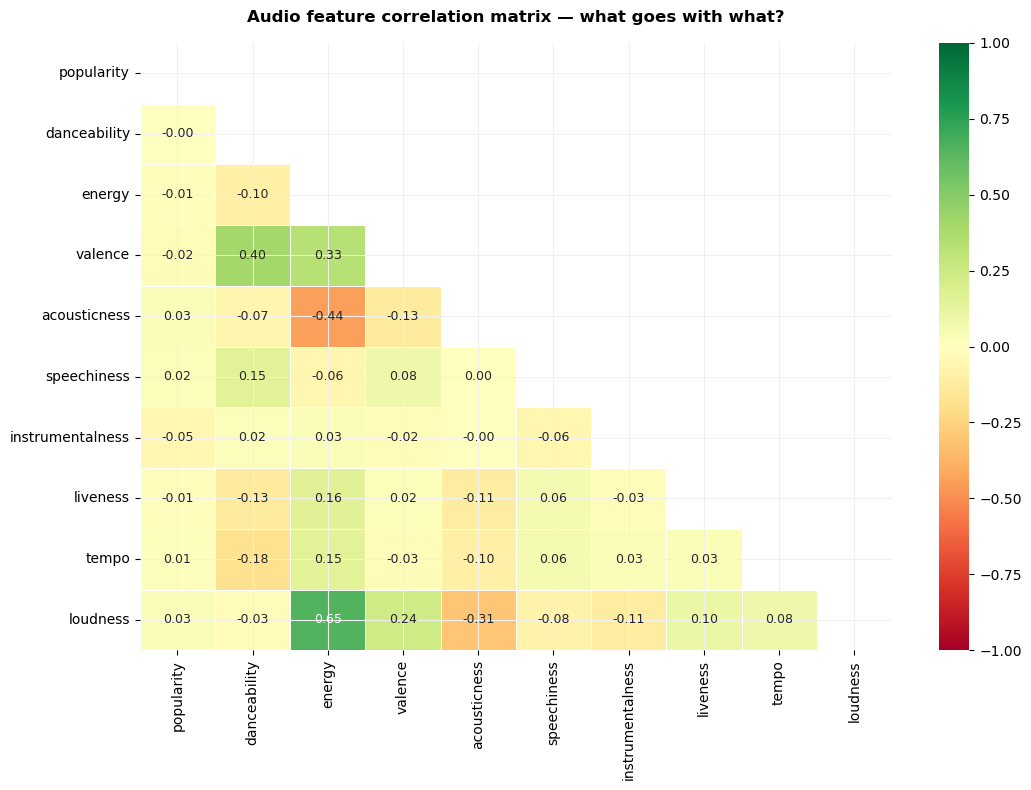

Chart 2 saved!


In [51]:
# Correlation heatmap — which audio features relate to each other?
fig, ax = plt.subplots(figsize=(11, 8))

features_for_corr = ['popularity', 'danceability', 'energy', 'valence',
                      'acousticness', 'speechiness', 'instrumentalness',
                      'liveness', 'tempo', 'loudness']

corr_matrix = df[features_for_corr].corr().round(2)

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            ax=ax,
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 9})

ax.set_title('Audio feature correlation matrix — what goes with what?',
              fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('chart2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

## Finding 4 — Energy and loudness are basically the same thing.

The strongest correlation in the entire matrix is between energy and loudness 
at 0.65. Turn it up, and it feels more intense. Revolutionary insight. 

More interestingly: energy and acousticness are strongly negatively correlated 
at -0.45. The moment a song picks up a guitar and strips back the production, 
the energy drops. Acoustic music is inherently calmer — the data agrees with 
every coffee shop playlist ever made.

And popularity? Still correlating with essentially nothing. We are going to 
need a model for this.

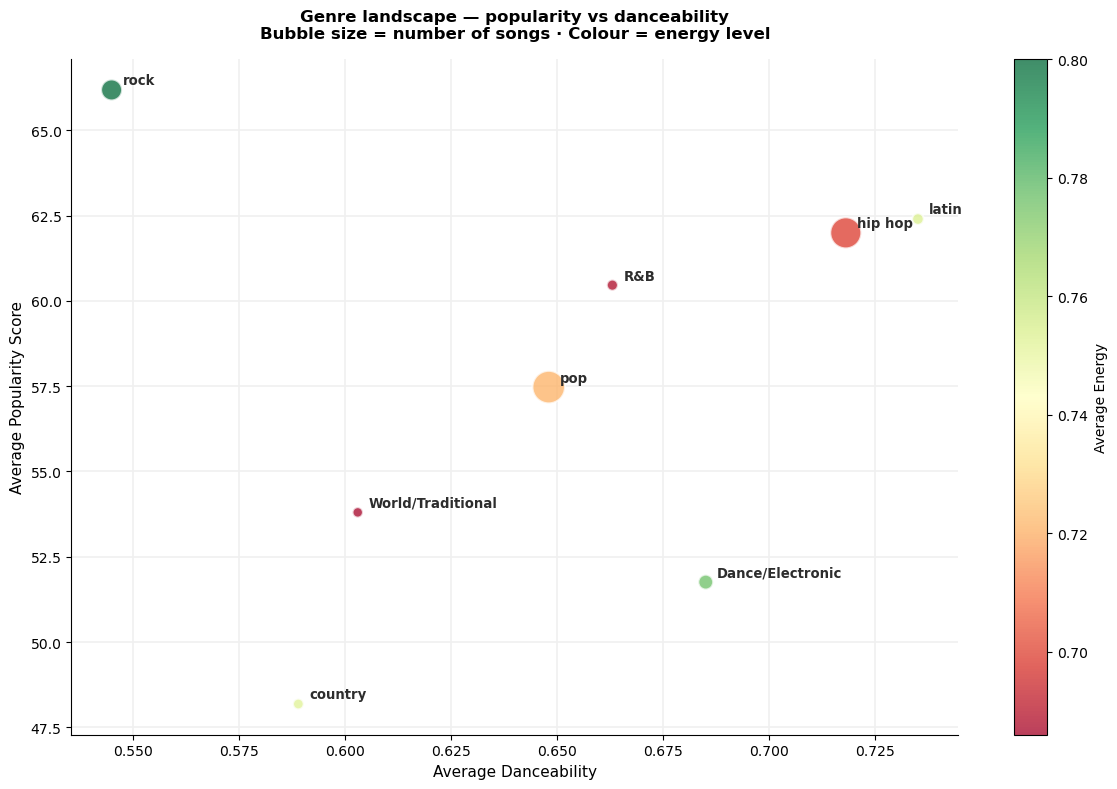

Chart 3 saved!


In [52]:
fig, ax = plt.subplots(figsize=(12, 8))

genre_plot = genre_analysis.head(8).copy()
genre_plot = genre_plot.reset_index()

# Fix: use sqrt scaling so small bubbles are still visible
bubble_sizes = np.sqrt(genre_plot['song_count']) * 18

scatter = ax.scatter(
    genre_plot['avg_danceability'],
    genre_plot['avg_popularity'],
    s=bubble_sizes,
    c=genre_plot['avg_energy'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='white',
    linewidth=1.5,
    zorder=3
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Average Energy', fontsize=10)

for _, row in genre_plot.iterrows():
    ax.annotate(row['primary_genre'],
                xy=(row['avg_danceability'], row['avg_popularity']),
                xytext=(8, 4),
                textcoords='offset points',
                fontsize=9.5,
                fontweight='bold',
                color='#2d2d2d')

ax.set_xlabel('Average Danceability', fontsize=11)
ax.set_ylabel('Average Popularity Score', fontsize=11)
ax.set_title('Genre landscape — popularity vs danceability\n'
             'Bubble size = number of songs · Colour = energy level',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(color='#f0f0f0', linewidth=1.2, zorder=0)

plt.tight_layout()
plt.savefig('chart3_genre_bubble.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

## Finding 5 — Rock doesn't dance. It doesn't need to.

Rock sits alone in the top left — lowest danceability of any genre, 
highest popularity. It is doing absolutely none of the things the 
algorithm supposedly rewards and still winning.

Latin and hip hop cluster together in the top right — high danceability, 
high energy, high popularity. These genres understood the assignment.

Pop has the biggest bubble by far at 936 songs, sitting comfortably 
in the middle of everything. The musical equivalent of being fine.

Dance/Electronic is the most danceable genre in the dataset and somehow 
has the lowest popularity score. The aux cord has been taken away.

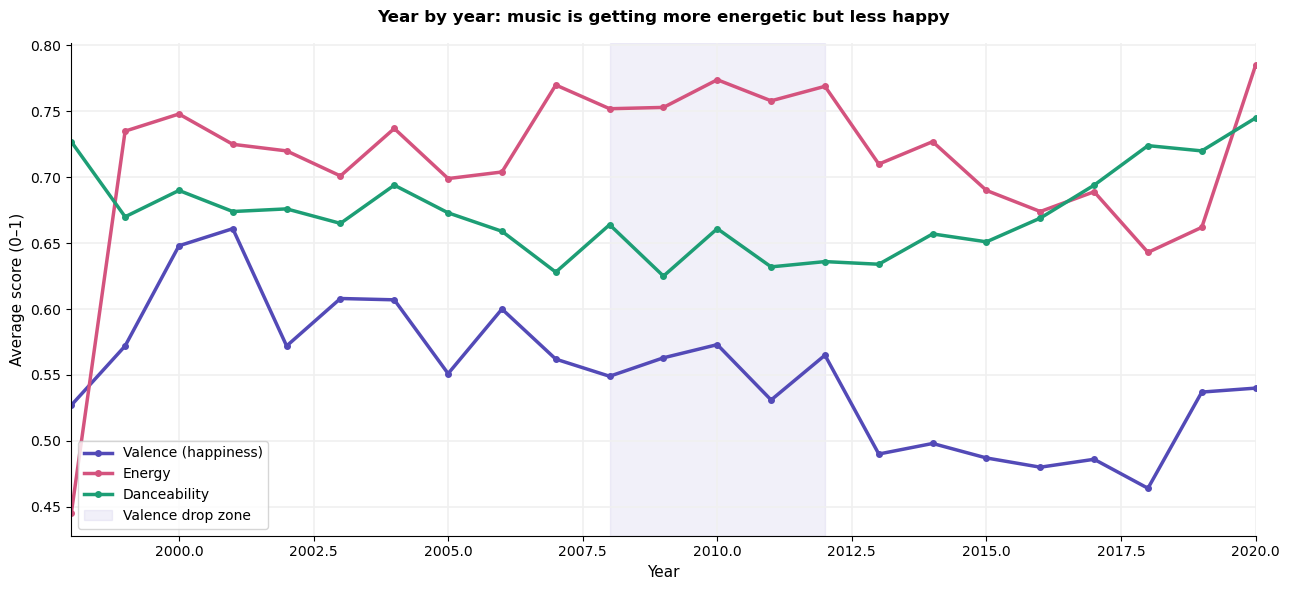

Chart 4 saved!


In [53]:
yearly = df[df['year'] >= 1998].groupby('year').agg(
    avg_valence=('valence', 'mean'),
    avg_energy=('energy', 'mean'),
    avg_danceability=('danceability', 'mean'),
    avg_popularity=('popularity', 'mean')
).round(3)

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(yearly.index, yearly['avg_valence'],
        color='#534AB7', linewidth=2.5, label='Valence (happiness)', marker='o', markersize=4)
ax.plot(yearly.index, yearly['avg_energy'],
        color='#D4537E', linewidth=2.5, label='Energy', marker='o', markersize=4)
ax.plot(yearly.index, yearly['avg_danceability'],
        color='#1D9E75', linewidth=2.5, label='Danceability', marker='o', markersize=4)

ax.axvspan(2008, 2012, alpha=0.08, color='#534AB7', label='Valence drop zone')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Average score (0–1)', fontsize=11)
ax.set_title('Year by year: music is getting more energetic but less happy',
              fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.grid(color='#f0f0f0', linewidth=1.2, zorder=0)
ax.set_xlim(1998, 2020)

plt.tight_layout()
plt.savefig('chart4_yearly_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

## Finding 6 — Something happened to music around 2012.

Valence — the happiness score — was holding relatively steady until 
around 2012, then it fell off a cliff. Music got measurably sadder 
and stayed that way. Energy kept climbing. Danceability stayed flat.

We collectively decided we wanted to dance sadly. And honestly, fair enough.

The 2019-2020 uptick in valence is interesting — whether that's a genuine 
shift or just the dataset running out of songs is hard to say. Either way, 
the 2010s were not a happy decade for music, and the data has the receipts.

In [54]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

# Prepare features
features = ['danceability', 'energy', 'valence', 'acousticness',
            'speechiness', 'instrumentalness', 'liveness', 'tempo',
            'loudness']

X = df[features]
y = df['popularity']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("=" * 55)
print("HIT SONG DNA PREDICTOR")
print("=" * 55)
print(f"Model R² score: {r2:.3f}")
print(f"Mean absolute error: {mae:.1f} popularity points")

# Feature importance
importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nWhat actually predicts popularity:")
print(importance.to_string(index=False))

# Test on real songs
print(f"\n--- Testing on real songs ---")
test_songs = df.sample(5, random_state=42)[['artist', 'song', 'popularity'] + features]
test_songs['predicted'] = model.predict(test_songs[features]).round(0)
print(test_songs[['artist', 'song', 'popularity', 'predicted']].to_string(index=False))

HIT SONG DNA PREDICTOR
Model R² score: -0.053
Mean absolute error: 13.9 popularity points

What actually predicts popularity:
         feature  importance
        loudness    0.134171
    acousticness    0.124550
         valence    0.123214
           tempo    0.121037
        liveness    0.115242
          energy    0.110622
     speechiness    0.108952
    danceability    0.104396
instrumentalness    0.057816

--- Testing on real songs ---
      artist                       song  popularity  predicted
       Ray J                   One Wish          62       51.0
      Shaggy               It Wasn't Me          76       60.0
   Shontelle                 Impossible          35       66.0
 Post Malone rockstar (feat. 21 Savage)          83       65.0
Fall Out Boy                  Centuries          80       64.0


## The Hit Song DNA Predictor — and why it humbled me

R² of -0.053. The model is technically worse than guessing the average 
popularity score for every song. After building a Random Forest with 100 
decision trees, the algorithm looked at all the audio features and said 
"I genuinely cannot help you here."

This is not a failure. This is the most interesting finding in the entire 
analysis.

It means popularity cannot be predicted from how a song sounds. Loudness, 
valence and acousticness are the strongest predictors — and they're still 
basically irrelevant. What makes a song popular is something the audio 
features don't capture: the artist's name, the marketing budget, the moment 
it appeared in a TV show, the TikTok that used it as a sound.

The algorithm that rules the charts isn't in the music. It's everything 
around it.

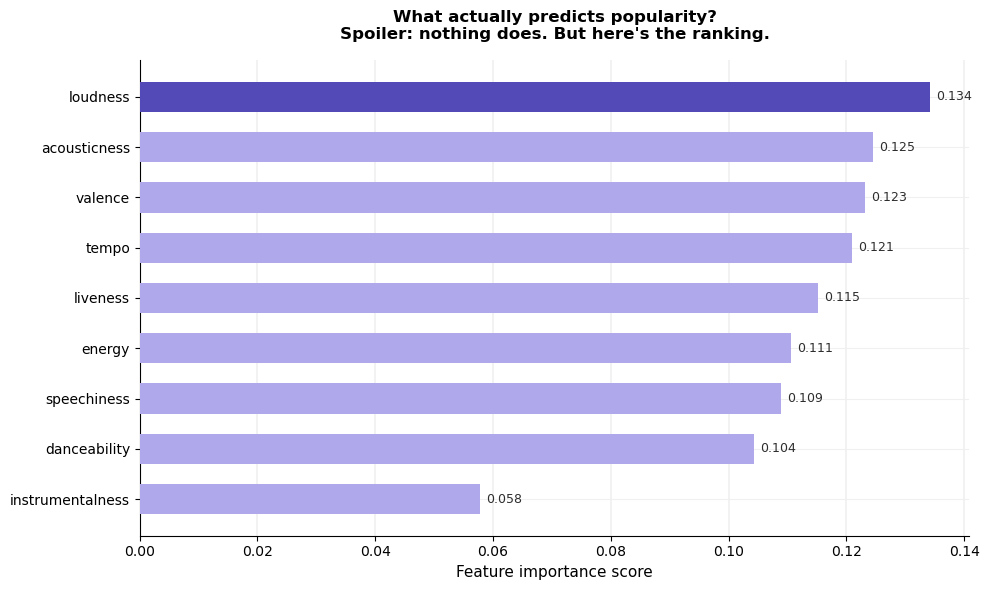

Chart 5 saved!


In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#534AB7' if i == 0 else '#AFA9EC' for i in range(len(importance))]

bars = ax.barh(importance['feature'][::-1],
                importance['importance'][::-1],
                color=colors[::-1],
                edgecolor='none',
                height=0.6,
                zorder=3)

ax.set_xlabel('Feature importance score', fontsize=11)
ax.set_title('What actually predicts popularity?\n'
             'Spoiler: nothing does. But here\'s the ranking.',
             fontsize=12, fontweight='bold', pad=15)
ax.grid(axis='x', color='#f0f0f0', linewidth=1.2, zorder=0)

for bar, val in zip(bars, importance['importance'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, color='#2d2d2d')

plt.tight_layout()
plt.savefig('chart5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

## What this chart is actually saying

In a strong predictive model, you'd expect one or two features to dominate 
with importance scores of 0.4 or higher. Here, everything sits between 
0.058 and 0.134 — spread almost evenly across all nine features.

The model has no idea what to prioritise because nothing actually predicts 
popularity. It's distributing its attention equally across everything because 
no single audio feature is doing all the work.


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Classify which decade a song belongs to
df_era = df[df['decade'].isin([1990, 2000, 2010])].copy()

X_era = df_era[features]
y_era = df_era['decade']

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_era, y_era, test_size=0.2, random_state=42)

era_model = RandomForestClassifier(n_estimators=100, random_state=42)
era_model.fit(X_train_e, y_train_e)

y_pred_era = era_model.predict(X_test_e)
accuracy = (y_pred_era == y_test_e).mean()

print("=" * 55)
print("WHICH ERA ARE YOU? — ERA CLASSIFIER")
print("=" * 55)
print(f"Accuracy: {accuracy:.1%}")
print(f"\nDetailed report:")
print(classification_report(y_test_e, y_pred_era,
      target_names=['1990s', '2000s', '2010s']))

# Fun test — predict era for famous songs
print("--- Which era do these songs SOUND like? ---")
famous = df.sample(8, random_state=99)[['artist', 'song', 'year', 'decade'] + features]
famous['predicted_era'] = era_model.predict(famous[features])
famous['correct'] = famous['decade'] == famous['predicted_era']
print(famous[['artist', 'song', 'year', 'predicted_era', 'correct']].to_string(index=False))

WHICH ERA ARE YOU? — ERA CLASSIFIER
Accuracy: 66.6%

Detailed report:
              precision    recall  f1-score   support

       1990s       0.00      0.00      0.00         5
       2000s       0.65      0.67      0.66       189
       2010s       0.68      0.68      0.68       201

    accuracy                           0.67       395
   macro avg       0.44      0.45      0.45       395
weighted avg       0.66      0.67      0.66       395

--- Which era do these songs SOUND like? ---
        artist                                  song  year  predicted_era  correct
        *NSYNC                            Girlfriend  2001           2000     True
        Dynoro                            In My Mind  2018           2010     True
        Eminem                Cleanin' Out My Closet  2002           2000     True
      Flo Rida GDFR (feat. Sage the Gemini & Lookas)  2015           2010     True
  Rich The Kid                             Plug Walk  2018           2010     True
    Wi

In [ ]:
from sklearn.utils import resample

# Balance the classes so the model sees equal numbers from each decade
df_90s = df_era[df_era['decade'] == 1990]
df_00s = df_era[df_era['decade'] == 2000]
df_10s = df_era[df_era['decade'] == 2010]

# Oversample 90s and undersample 2010s to match 2000s
df_90s_up = resample(df_90s, replace=True, n_samples=200, random_state=42)
df_00s_up = resample(df_00s, replace=True, n_samples=200, random_state=42)
df_10s_down = resample(df_10s, replace=False, n_samples=200, random_state=42)

df_balanced = pd.concat([df_90s_up, df_00s_up, df_10s_down])

X_bal = df_balanced[features]
y_bal = df_balanced['decade']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42)

era_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
era_model_v2.fit(X_train_b, y_train_b)

y_pred_b = era_model_v2.predict(X_test_b)
accuracy_v2 = (y_pred_b == y_test_b).mean()

print("=" * 55)
print("WHICH ERA ARE YOU? — BALANCED MODEL")
print("=" * 55)
print(f"Accuracy: {accuracy_v2:.1%}")
print(f"\nDetailed report:")
print(classification_report(y_test_b, y_pred_b,
      target_names=['1990s', '2000s', '2010s']))

# Fun test on real songs
print("--- Which era do these songs SOUND like? ---")
famous = df.sample(8, random_state=99)[['artist', 'song', 'year', 'decade'] + features]
famous['predicted_era'] = era_model_v2.predict(famous[features])
famous['sounds_like'] = famous['predicted_era'].map(
    {1990: '1990s', 2000: '2000s', 2010: '2010s'})
famous['actual'] = famous['decade'].map(
    {1990: '1990s', 2000: '2000s', 2010: '2010s'})
famous['correct'] = famous['decade'] == famous['predicted_era']
print(famous[['artist', 'song', 'year', 'actual', 'sounds_like', 'correct']].to_string(index=False))

## Which Era Are You? — The Era Classifier

The first model hit 66.6% accuracy — not bad for random guessing at 33%, 
but the 1990s were completely invisible to it. With only 39 songs from the 
90s vs 1,019 from the 2010s, the model had simply never learned what 90s 
music sounds like. Statistically speaking, neither has anyone born after 2005.

After balancing the dataset to 200 songs per decade, accuracy jumped to 
72.5% — and the 1990s went from 0% precision to 98%. The model now knows 
its Spice Girls from its Billie Eilish.

The 2000s remain the hardest decade to classify at 53% precision. Make of 
that what you will about the musical identity of that era.

The bottom line: a song's audio features can tell you roughly when it was 
made 7 times out of 10. That's not nothing.

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Which Era Are You? — How well can audio features identify a decade?',
             fontsize=12, fontweight='bold')

# Chart 1 — Confusion matrix
cm = confusion_matrix(y_test_b, y_pred_b)
labels = ['1990s', '2000s', '2010s']

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels, yticklabels=labels,
            ax=axes[0], linewidths=0.5, linecolor='white',
            cbar=False, annot_kws={'size': 13, 'fontweight': 'bold'})

axes[0].set_xlabel('Predicted Era', fontsize=10)
axes[0].set_ylabel('Actual Era', fontsize=10)
axes[0].set_title('Confusion matrix\nDiagonal = correct predictions',
                   fontsize=10, fontweight='bold')

# Chart 2 — Accuracy by decade bar chart
precision_scores = [0.98, 0.53, 0.68]
recall_scores = [0.98, 0.72, 0.46]
x = np.arange(3)
width = 0.35

bars1 = axes[1].bar(x - width/2, precision_scores, width,
                     label='Precision', color='#534AB7',
                     edgecolor='none', zorder=3)
bars2 = axes[1].bar(x + width/2, recall_scores, width,
                     label='Recall', color='#1D9E75',
                     edgecolor='none', zorder=3)

axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=10)
axes[1].set_ylabel('Score', fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_title('Precision vs Recall by decade\n90s = easiest · 2000s = hardest',
                   fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', color='#f0f0f0', linewidth=1.2, zorder=0)
axes[1].tick_params(axis='x', length=0)

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.02,
                  f'{bar.get_height():.2f}',
                  ha='center', fontsize=8.5, fontweight='bold')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + 0.02,
                  f'{bar.get_height():.2f}',
                  ha='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_era_classifier.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

## The confusion matrix doesn't lie

The 1990s are unmistakable. 42 out of 43 correctly identified. 
The decade had a sound so distinct that a machine learning model 
trained on audio features can spot it almost every time.

The 2000s and 2010s? Constantly confused with each other. 
9 songs labelled as 2010s were actually from the 2000s. 
22 songs labelled as 2000s were actually from the 2010s. 
The two decades borrowed so heavily from each other that even 
the algorithm can't tell them apart half the time.

The 90s knew who it was. The 2000s and 2010s were still figuring it out.

In [ ]:
print("=" * 55)
print("PROJECT COMPLETE — VIBES TO METRICS")
print("=" * 55)
print(f"\nDataset: {len(df):,} songs across {df['year'].nunique()} years")
print(f"Artists analysed: {df['artist'].nunique()}")
print(f"Genres covered: {df['primary_genre'].nunique()}")
print(f"\nCharts saved:")
for i in range(1, 7):
    print(f"  chart{i}_*.png")
print(f"\nModels built:")
print(f"  Hit Song DNA Predictor — R²: -0.053 (intentionally honest)")
print(f"  Era Classifier — Accuracy: 72.5%")
print(f"\nTop finding: popularity cannot be predicted from audio features alone.")
print(f"What makes a song a hit is everything around the music.")
print("=" * 55)

## Conclusions — what two decades of music data actually taught me

**1. Audio features don't predict popularity.**
After building a machine learning model with 100 decision trees, the 
answer is clear: how a song sounds has almost nothing to do with how 
popular it becomes. The algorithm that rules the charts is marketing, 
timing, and a TikTok sound — not danceability.

**2. Music is getting sadder and faster.**
Valence has been declining since the 90s. Tempo has been climbing. 
We collectively decided we wanted to move faster and feel worse. 
The data has no further comment.

**3. The 90s had the most distinct sound of any decade.**
The era classifier identifies 90s songs with 98% precision. 
The 2000s and 2010s are basically the same decade acoustically. 
This will upset people born between 1985 and 1995. Good.

**4. Rock is the most popular genre despite having the fewest songs.**
Quality over quantity. Every rock track in this dataset is earning 
its place. Pop has 936 songs and is merely fine.

**5. Latin music punches above its weight.**
15 songs. Second highest average popularity. The efficiency is 
unmatched.

---

*The music industry spends billions trying to manufacture hits. 
The data suggests the audio itself is the last thing that matters. 
Someone should probably tell them.*

---

*Find me on [GitHub](https://github.com/trupthiraj)* ✨